# StarDist Parameter Test

This notebook allows to compare multiple StarDist parameter combinations to be able to find the best one. 

The tested parameter combinations are in the table below. Every combination is tested on the original and the preprocessed images; the resulting images are saved with very clear names, stating the name of the Tumuroide, the parameter combination, and the image it was tested on. 

---
## Combinations to test

| Combo | prob_thresh | nms_thresh | Why |
|-------|-------------|------------|-----|
| params1 | 0.5 | 0.4 | Default baseline for fluorescence images |
| params2 | 0.3 | 0.4 | Lower prob threshold; detects more (less certain) nuclei |
| params3 | 0.7 | 0.4 | Higher prob threshold ; only confident detections |
| params4 | 0.5 | 0.2 | Stricter NMS ; reduces overlap between adjacent nuclei |
| params5 | 0.5 | 0.6 | Relaxed NMS ; allows more overlap, may merge touching nuclei |
| params6 | 0.3 | 0.2 | More detections + strict NMS ; finds dim nuclei without merging them |
| params7 | 0.3 | 0.3 | Balanced, good starting point when nuclei are densely packed |

**prob_thresh** : probability threshold to accept a detection (model default around 0.5). Lower = more detections, more false positives.  
**nms_thresh** : non-maximum suppression overlap threshold (model default around 0.4). Lower = less overlap allowed between detected nuclei.

---
## Section 1 : Setup

Here we choose the region to crop, and the preprocessing parameters. This cell builds img_original and img_preprocessed, which are used in all cells below.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tifffile
import os

from skimage import measure, exposure
from skimage.color import label2rgb
from skimage.filters import unsharp_mask

Image loaded : 23797 x 23935 px  —  dtype float32
Memory       : 2.28 GB
img_original ready.


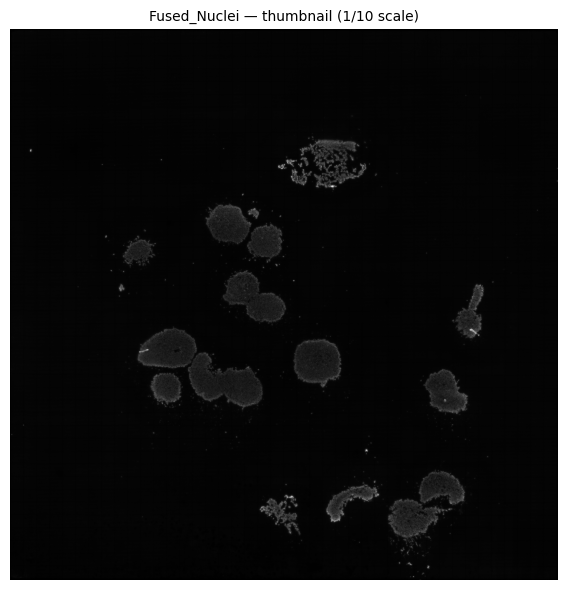

In [4]:
# IMAGE AND OUTPUT
IMAGE_PATH    = '../../level_1/pics/Fused_Nuclei.tif'
IMAGE_TAG     = 'Fused_Nuclei'
OUTPUT_FOLDER = 'stardist_big_param_test_results'

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# tifffile handles large TIFFs that PIL cannot open
img_full = tifffile.imread(IMAGE_PATH)

# normalize to [0, 1] float32 (float32 uses half the memory of float64)
img_full = img_full.astype(np.float32)
img_original = (img_full - img_full.min()) / (img_full.max() - img_full.min())

h, w = img_original.shape
print(f'Image loaded : {w} x {h} px  —  dtype float32')
print(f'Memory       : {img_original.nbytes / 1e9:.2f} GB')
print('img_original ready.')

# show a downsampled thumbnail (cannot display 24K x 24K in a notebook)
THUMB_FACTOR = 10
thumb = img_original[::THUMB_FACTOR, ::THUMB_FACTOR]
plt.figure(figsize=(6, 6))
plt.imshow(thumb, cmap='gray')
plt.title(f'Fused_Nuclei — thumbnail (1/{THUMB_FACTOR} scale)', fontsize=10)
plt.axis('off')
plt.tight_layout()
plt.show()

In [5]:
from scipy.ndimage import gaussian_filter

# PREPROCESSING TUNING
CLIP_PERCENTILE = 100    # 100 = no clipping ; lower to remove top bright pixels before CLAHE
BG_SIGMA        = 50     # background blur radius (px) — must be >> nucleus diameter (~24px)
CLAHE_CLIP      = 0.02   # CLAHE strength : 0.01 (light) ; 0.05 (strong)
CLAHE_KERNEL    = 256    # CLAHE tile size (px) — smaller = more local adaptation
SHARP_RADIUS    = 1.5    # sharpening radius in px
SHARP_AMOUNT    = 2.0    # sharpening strength

# step 1 : optional pixel clipping
p            = np.percentile(img_original, CLIP_PERCENTILE)
img_clipped  = np.clip(img_original, 0, p) / p

# step 2 : background subtraction
# large Gaussian estimates the uneven illumination field, then subtract it
# result: nuclei in dark regions become as visible as nuclei in bright regions
background  = gaussian_filter(img_clipped, sigma=BG_SIGMA)
img_bg_sub  = np.clip(img_clipped - background + background.mean(), 0, 1).astype(np.float32)

# step 3 : local CLAHE
img_clahe   = exposure.equalize_adapthist(img_bg_sub, clip_limit=CLAHE_CLIP, kernel_size=CLAHE_KERNEL)

# step 4 : unsharp mask
img_preprocessed = np.clip(
    unsharp_mask(img_clahe, radius=SHARP_RADIUS, amount=SHARP_AMOUNT), 0, 1
).astype(np.float32)

print('Preprocessing done')
print(f'  CLIP={CLIP_PERCENTILE}  BG_SIGMA={BG_SIGMA}  CLAHE={CLAHE_CLIP}  kernel={CLAHE_KERNEL}  sharp={SHARP_AMOUNT}')
print('img_preprocessed ready.')

Preprocessing done
  CLIP=100  BG_SIGMA=50  CLAHE=0.02  kernel=256  sharp=2.0
img_preprocessed ready.


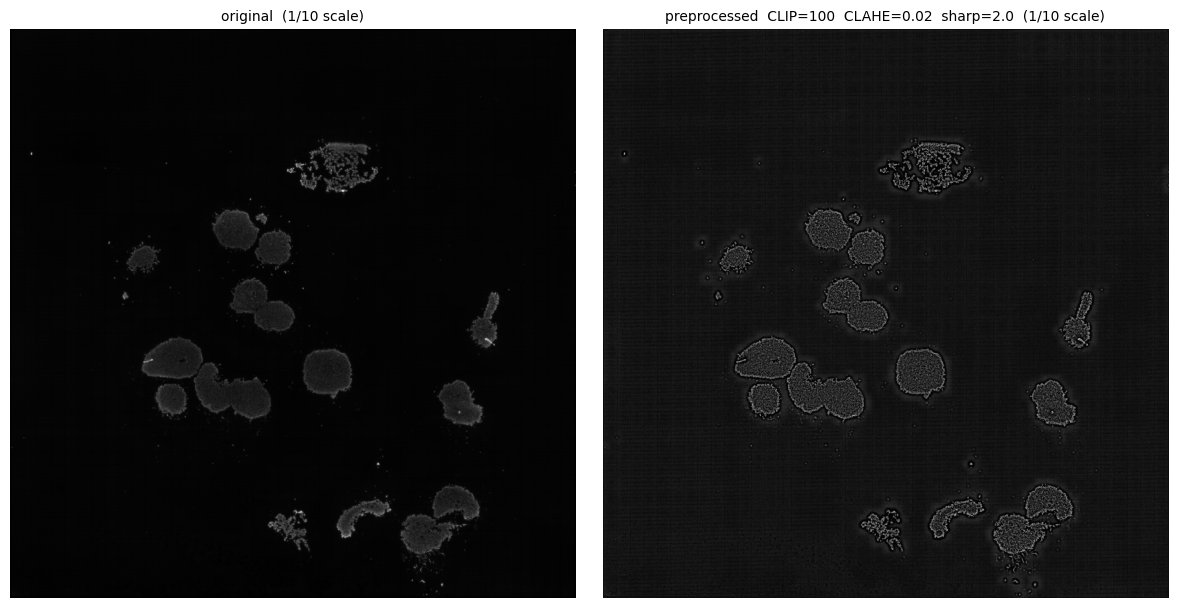

Preprocessing comparison done.


In [6]:
# compare original vs preprocessed thumbnail
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

thumb_orig = img_original    [::THUMB_FACTOR, ::THUMB_FACTOR]
thumb_prep = img_preprocessed[::THUMB_FACTOR, ::THUMB_FACTOR]

axes[0].imshow(thumb_orig, cmap='gray')
axes[0].set_title(f'original  (1/{THUMB_FACTOR} scale)', fontsize=10)
axes[0].axis('off')

axes[1].imshow(thumb_prep, cmap='gray')
axes[1].set_title(
    f'preprocessed  CLIP={CLIP_PERCENTILE}  CLAHE={CLAHE_CLIP}  sharp={SHARP_AMOUNT}  (1/{THUMB_FACTOR} scale)',
    fontsize=10
)
axes[1].axis('off')

plt.tight_layout()
plt.show()
print('Preprocessing comparison done.')

---
## Section 2 : Load model

We specify the cellpose model to use, and the presence of GPU.
Ran once per session.

In [7]:
from stardist.models import StarDist2D

model_sd = StarDist2D.from_pretrained('2D_versatile_fluo')
print('StarDist model loaded.')
print(f'  default prob_thresh : {model_sd.thresholds.prob:.3f}')
print(f'  default nms_thresh  : {model_sd.thresholds.nms:.3f}')

2026-06-03 10:22:08.446503: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Found model '2D_versatile_fluo' for 'StarDist2D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.479071, nms_thresh=0.3.
StarDist model loaded.
  default prob_thresh : 0.479
  default nms_thresh  : 0.300


---
## Section 3 : Run

We set `COMBO_NAME` to the combination to test (see table above), adjust the parameters, and run this cell.
Set `SAVE = True` to save the figures; two files will be created, one for original and one for preprocessed.

In [8]:
import time
from stardist.models import StarDist2D
from csbdeep.utils import normalize as stardist_normalize

# PARAM COMBO
COMBO_NAME   = 'fused_extra_preprocessed_100_param1'

IMAGE_CHOICE = 'preprocessed'   # 'original' or 'preprocessed'

PROB_THRESH  = 0.5
NMS_THRESH   = 0.4

# n_tiles : StarDist splits the image into a grid of overlapping tiles and stitches them back.
# Needed for large images that do not fit in GPU/CPU memory at once.
# (8, 8) = 64 tiles of ~3000 x 3000 px each — adjust up if memory errors occur.
N_TILES = (8, 8)

SAVE = True

img_input = img_original if IMAGE_CHOICE == 'original' else img_preprocessed
img_norm  = stardist_normalize(img_input, 1, 99.8)

print(f'Running StarDist on {IMAGE_CHOICE}  ({img_norm.shape[1]} x {img_norm.shape[0]} px)')
print(f'  prob={PROB_THRESH}  nms={NMS_THRESH}  n_tiles={N_TILES}')
print('  (this will take several minutes on CPU)')

t0 = time.time()
labels_raw, _ = model_sd.predict_instances(
    img_norm,
    prob_thresh=PROB_THRESH,
    nms_thresh=NMS_THRESH,
    n_tiles=N_TILES
)
elapsed = time.time() - t0
print(f'  Done in {elapsed/60:.1f} min  —  {len(np.unique(labels_raw)) - 1} cells detected')

Running StarDist on preprocessed  (23797 x 23935 px)
  prob=0.5  nms=0.4  n_tiles=(8, 8)
  (this will take several minutes on CPU)


100%|███████████████████████████████████████████| 64/64 [08:01<00:00,  7.53s/it]


  Done in 10.7 min  —  41245 cells detected


Total detections : 41245

   pct   size (px²)
    1%           57
    5%           76
   10%          104
   25%          213
   50%          385
   75%          622
   90%         1029
   95%         1436
   99%         3053

MIN candidates  (removes detections below threshold)
     MIN    removed       kept    % removed
      30          6      41239         0.0%
      50        152      41093         0.4%
      75       1933      39312         4.7%
     100       3822      37423         9.3%
     150       6796      34449        16.5%
     200       9543      31702        23.1%
     300      15193      26052        36.8%

MAX candidates  (removes detections above threshold)
     MAX    removed       kept    % removed
    1000       4347      36898        10.5%
    1500       1882      39363         4.6%
    2000       1060      40185         2.6%
    2500        647      40598         1.6%
    3000        428      40817         1.0%
    4000        212      41033         0.5%
    50

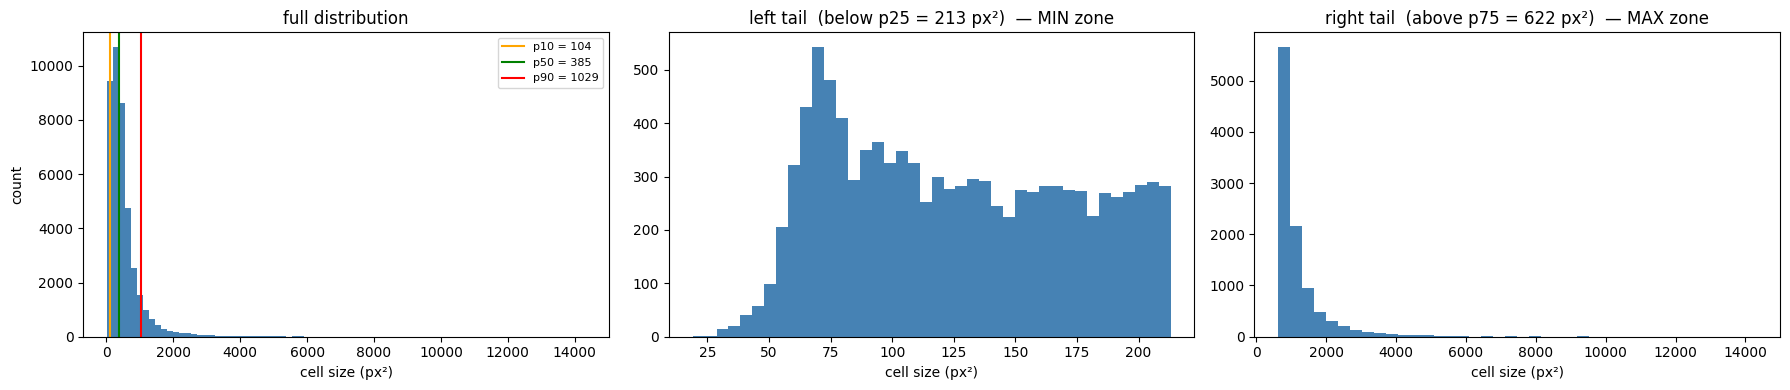

Distribution analysis done.


In [23]:
# size distribution analysis — run after predict_instances, before size filter
tailles = np.bincount(labels_raw.flatten())[1:]
tailles = tailles[tailles > 0]   # remove ghost IDs
n_total = len(tailles)

p10, p25, p50, p75, p90 = [int(np.percentile(tailles, p)) for p in [10, 25, 50, 75, 90]]

# percentile table
print(f'Total detections : {n_total}')
print()
print(f'  {"pct":>4}   {"size (px²)":>10}')
for pct in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    print(f'  {pct:>3}%   {int(np.percentile(tailles, pct)):>10}')

# MIN candidates — how many detections are removed by each cutoff
print()
print('MIN candidates  (removes detections below threshold)')
print(f'  {"MIN":>6}   {"removed":>8}   {"kept":>8}   {"% removed":>10}')
for m in [30, 50, 75, 100, 150, 200, 300]:
    r = int((tailles < m).sum())
    print(f'  {m:>6}   {r:>8}   {n_total - r:>8}   {100 * r / n_total:>9.1f}%')

# MAX candidates — how many detections are removed by each cutoff
print()
print('MAX candidates  (removes detections above threshold)')
print(f'  {"MAX":>6}   {"removed":>8}   {"kept":>8}   {"% removed":>10}')
for m in [1000, 1500, 2000, 2500, 3000, 4000, 5000]:
    r = int((tailles > m).sum())
    print(f'  {m:>6}   {r:>8}   {n_total - r:>8}   {100 * r / n_total:>9.1f}%')

# three panels: full distribution, left tail (MIN zone), right tail (MAX zone)
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(tailles, bins=80, color='steelblue', edgecolor='none')
for val, col, lbl in [(p10, 'orange', f'p10 = {p10}'),
                      (p50, 'green',  f'p50 = {p50}'),
                      (p90, 'red',    f'p90 = {p90}')]:
    axes[0].axvline(val, color=col, lw=1.5, label=lbl)
axes[0].set_xlabel('cell size (px²)')
axes[0].set_ylabel('count')
axes[0].set_title('full distribution')
axes[0].legend(fontsize=8)

axes[1].hist(tailles[tailles <= p25], bins=40, color='steelblue', edgecolor='none')
axes[1].set_xlabel('cell size (px²)')
axes[1].set_title(f'left tail  (below p25 = {p25} px²)  — MIN zone')

axes[2].hist(tailles[tailles >= p75], bins=40, color='steelblue', edgecolor='none')
axes[2].set_xlabel('cell size (px²)')
axes[2].set_title(f'right tail  (above p75 = {p75} px²)  — MAX zone')

plt.tight_layout()
plt.show()
print('Distribution analysis done.')

Size filter (50–4000 px²) : 40881 cells kept


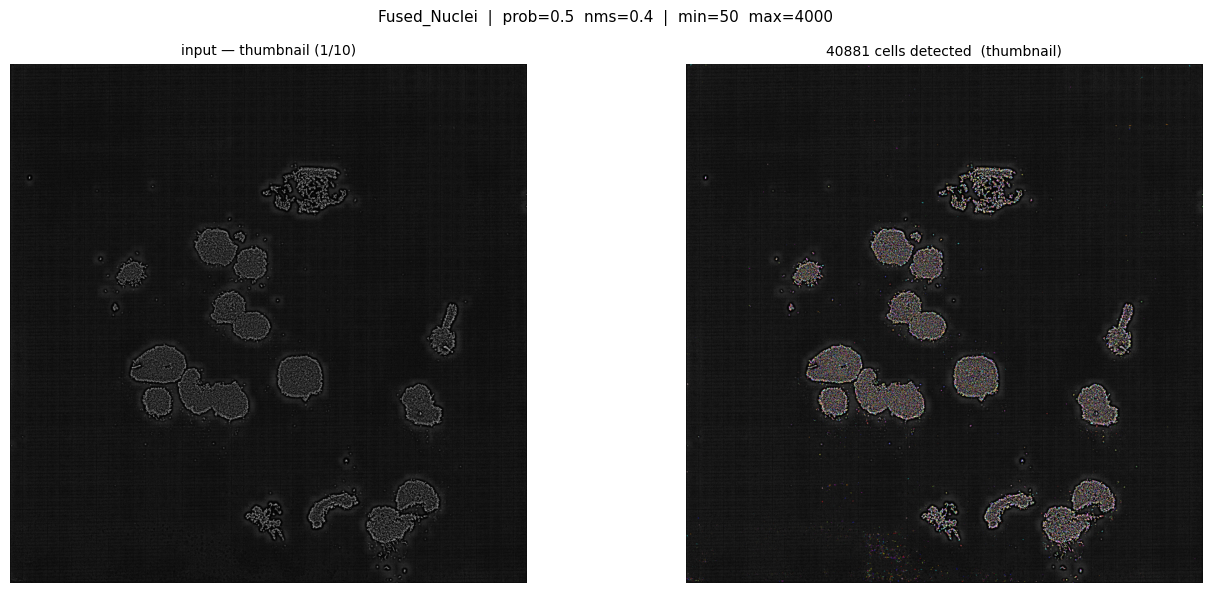

Mask saved : stardist_big_param_test_results/Fused_Nuclei_fused_extra_preprocessed_100_param1_mask.npy  ((23935, 23797), int32)


In [24]:
# SIZE FILTER
MIN_CELL_SIZE = 50    # px²
MAX_CELL_SIZE = 4000   # px²

from skimage.measure import regionprops_table
props = regionprops_table(labels_raw, properties=['label', 'area'])
valid = props['label'][(props['area'] >= MIN_CELL_SIZE) & (props['area'] <= MAX_CELL_SIZE)]
labels = labels_raw * np.isin(labels_raw, valid)
n_kept = len(np.unique(labels)) - 1
print(f'Size filter ({MIN_CELL_SIZE}–{MAX_CELL_SIZE} px²) : {n_kept} cells kept')

# display a thumbnail — the full 24K x 24K image cannot be rendered in a notebook
THUMB_FACTOR = 10
thumb_img    = img_norm[::THUMB_FACTOR, ::THUMB_FACTOR]
thumb_labels = labels[::THUMB_FACTOR, ::THUMB_FACTOR]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(thumb_img, cmap='gray')
axes[0].set_title(f'input — thumbnail (1/{THUMB_FACTOR})', fontsize=10)
axes[0].axis('off')
axes[1].imshow(np.clip(label2rgb(thumb_labels, image=thumb_img, bg_label=0, alpha=0.4), 0, 1))
axes[1].set_title(f'{n_kept} cells detected  (thumbnail)', fontsize=10)
axes[1].axis('off')
plt.suptitle(
    f'{IMAGE_TAG}  |  prob={PROB_THRESH}  nms={NMS_THRESH}  |  min={MIN_CELL_SIZE}  max={MAX_CELL_SIZE}',
    fontsize=11
)
plt.tight_layout()
plt.show()

# save mask
if SAVE:
    mask_path = os.path.join(OUTPUT_FOLDER, f'{IMAGE_TAG}_{COMBO_NAME}_mask.npy')
    np.save(mask_path, labels)
    print(f'Mask saved : {mask_path}  ({labels.shape}, {labels.dtype})')

---
## Section 4 : Spatial filtering

Two optional filters to remove detections outside the tumoroids.

**Cell 4a — polygon mask** : uses the tumoroid boundary annotations (polygones_tumoroids.json) to remove all cells detected outside any tumoroid. This is the primary filter.

**Cell 4b — isolation filter** : removes cells with too few neighbors within a given radius. Secondary filter for sparse artifact detections that may remain inside the polygon boundaries.

Polygon mask  (9 tumoroids)
  input  : 40881 cells
  output : 21643 cells kept  (19238 removed outside tumoroids)


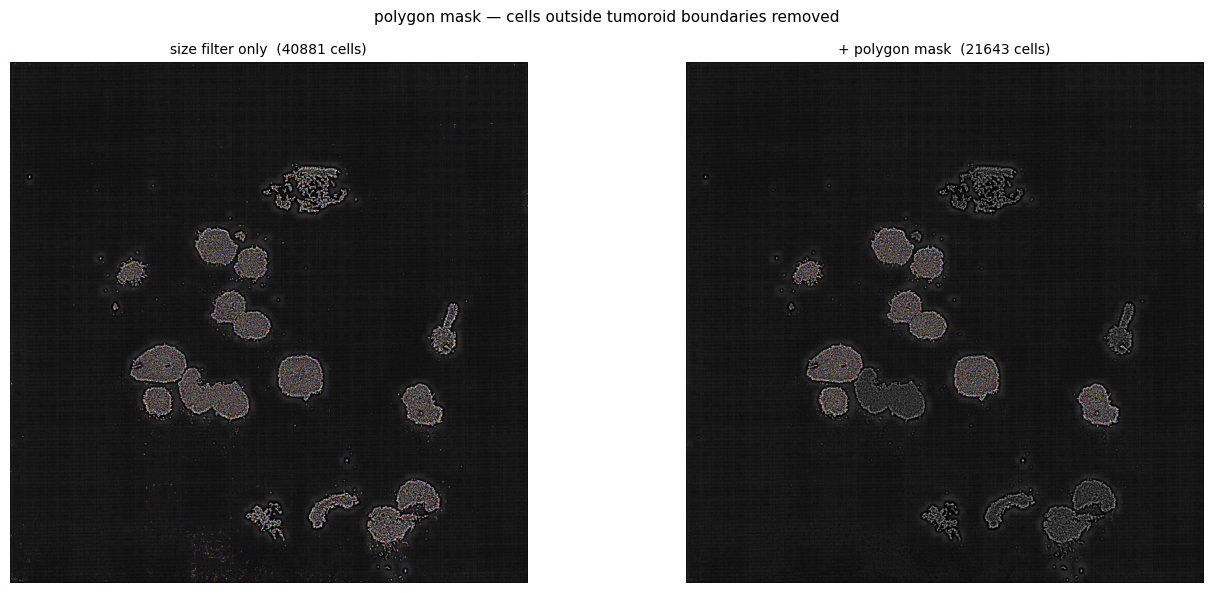

Polygon mask done  ->  labels_poly


In [25]:
import json
from skimage.draw import polygon as draw_polygon

POLYGON_PATH = '../tumoroides/polygones_tumoroids.json'

# spot coordinates in the JSON -> full image pixel coordinates
# full image is 23797 x 23935 px, spot coordinate space is [0, 1000]
h_img, w_img = labels.shape
SCALE_X = w_img / 1000.0   # 23.797
SCALE_Y = h_img / 1000.0   # 23.935

with open(POLYGON_PATH) as f:
    polygons_spot = json.load(f)

# build a binary mask : True inside any tumoroid, False outside
tumoroid_mask = np.zeros((h_img, w_img), dtype=bool)

for name, coords in polygons_spot.items():
    xs = np.array([c[0] * SCALE_X for c in coords])
    ys = np.array([c[1] * SCALE_Y for c in coords])
    rr, cc = draw_polygon(ys, xs, shape=(h_img, w_img))
    tumoroid_mask[rr, cc] = True

# apply mask to labels (size-filtered) — independent of the isolation filter
labels_poly = labels * tumoroid_mask
n_poly = len(np.unique(labels_poly)) - 1
n_removed_poly = (len(np.unique(labels)) - 1) - n_poly

print(f'Polygon mask  ({len(polygons_spot)} tumoroids)')
print(f'  input  : {len(np.unique(labels)) - 1} cells')
print(f'  output : {n_poly} cells kept  ({n_removed_poly} removed outside tumoroids)')

thumb_poly = labels_poly[::THUMB_FACTOR, ::THUMB_FACTOR]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(np.clip(label2rgb(thumb_labels, image=thumb_img, bg_label=0, alpha=0.4), 0, 1))
axes[0].set_title(f'size filter only  ({len(np.unique(labels)) - 1} cells)', fontsize=10)
axes[0].axis('off')
axes[1].imshow(np.clip(label2rgb(thumb_poly, image=thumb_img, bg_label=0, alpha=0.4), 0, 1))
axes[1].set_title(f'+ polygon mask  ({n_poly} cells)', fontsize=10)
axes[1].axis('off')
plt.suptitle('polygon mask — cells outside tumoroid boundaries removed', fontsize=11)
plt.tight_layout()
plt.show()
print('Polygon mask done  ->  labels_poly')

Isolation filter  (radius=80 px  min_neighbors=6)
  input  : 21643 cells  (after polygon mask)
  output : 21218 cells kept  (425 isolated cells removed)


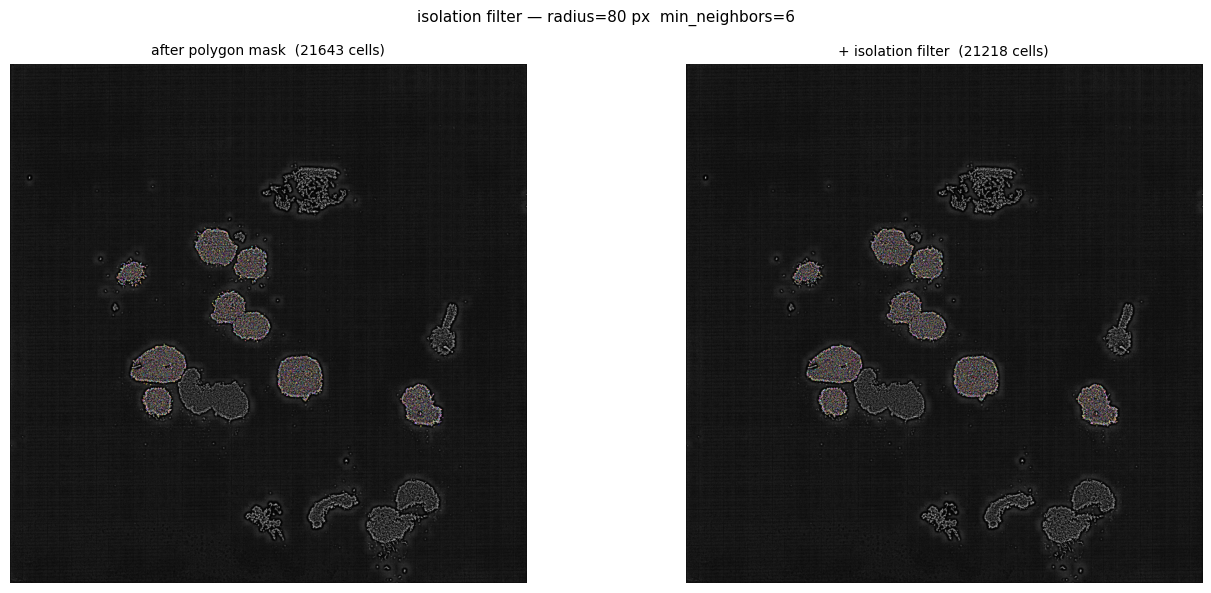

Isolation filter done  ->  labels_iso


In [72]:
from scipy.spatial import cKDTree
from skimage.measure import regionprops_table

# ISOLATION FILTER PARAMETERS
NEIGHBOR_RADIUS = 80   # px — radius to search for neighbors (~3x nucleus diameter)
MIN_NEIGHBORS   = 6    # minimum number of neighbors required to keep a cell

# applied to labels_poly (polygon-masked result)
props_iso     = regionprops_table(labels_poly, properties=['label', 'centroid'])
labels_iso_in = props_iso['label']

if len(labels_iso_in) == 0:
    print('No cells to filter.')
else:
    cents = np.column_stack([props_iso['centroid-0'], props_iso['centroid-1']])
    tree  = cKDTree(cents)

    counts    = np.array([
        len(tree.query_ball_point(c, NEIGHBOR_RADIUS)) - 1
        for c in cents
    ])
    valid_iso  = labels_iso_in[counts >= MIN_NEIGHBORS]
    labels_iso = labels_poly * np.isin(labels_poly, valid_iso)
    n_iso      = len(np.unique(labels_iso)) - 1
    n_removed_iso = len(labels_iso_in) - n_iso

    print(f'Isolation filter  (radius={NEIGHBOR_RADIUS} px  min_neighbors={MIN_NEIGHBORS})')
    print(f'  input  : {len(labels_iso_in)} cells  (after polygon mask)')
    print(f'  output : {n_iso} cells kept  ({n_removed_iso} isolated cells removed)')

    thumb_iso = labels_iso[::THUMB_FACTOR, ::THUMB_FACTOR]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(np.clip(label2rgb(thumb_poly, image=thumb_img, bg_label=0, alpha=0.4), 0, 1))
    axes[0].set_title(f'after polygon mask  ({len(labels_iso_in)} cells)', fontsize=10)
    axes[0].axis('off')
    axes[1].imshow(np.clip(label2rgb(thumb_iso, image=thumb_img, bg_label=0, alpha=0.4), 0, 1))
    axes[1].set_title(f'+ isolation filter  ({n_iso} cells)', fontsize=10)
    axes[1].axis('off')
    plt.suptitle(f'isolation filter — radius={NEIGHBOR_RADIUS} px  min_neighbors={MIN_NEIGHBORS}', fontsize=11)
    plt.tight_layout()
    plt.show()
    print('Isolation filter done  ->  labels_iso')

In [70]:
# save colored thumbnail as PNG
from matplotlib.colors import hsv_to_rgb

thumb_save_path = os.path.join(OUTPUT_FOLDER, f'{IMAGE_TAG}_{COMBO_NAME}_thumbnail.png')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(thumb_img, cmap='gray')
axes[0].set_title(f'input — 1/{THUMB_FACTOR} scale', fontsize=10)
axes[0].axis('off')
axes[1].imshow(np.clip(label2rgb(thumb_labels, image=thumb_img, bg_label=0, alpha=0.4), 0, 1))
axes[1].set_title(f'{n_kept} cells detected', fontsize=10)
axes[1].axis('off')
plt.suptitle(
    f'{IMAGE_TAG}  |  prob={PROB_THRESH}  nms={NMS_THRESH}  |  min={MIN_CELL_SIZE}  max={MAX_CELL_SIZE}',
    fontsize=11
)
plt.tight_layout()
plt.savefig(thumb_save_path, dpi=150, bbox_inches='tight')
plt.close()
print(f'Saved: {thumb_save_path}')

Saved: stardist_big_param_test_results/Fused_Nuclei_fused_extra_preprocessed_100_param1_thumbnail.png


Saved: stardist_big_param_test_results/Fused_Nuclei_fused_extra_preprocessed_100_param1_2filters_crop_8000_7000.png


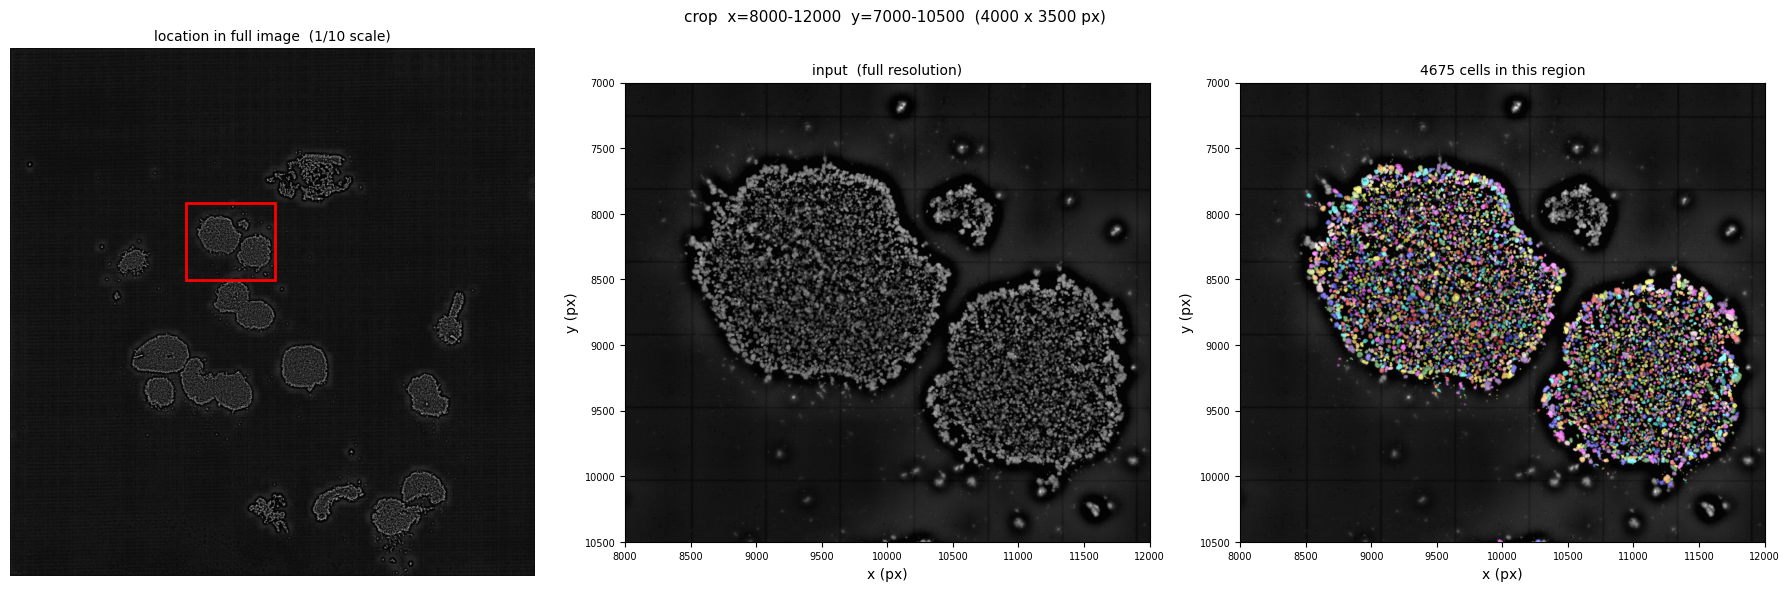

In [71]:
from matplotlib.patches import Rectangle

# ZOOM PARAMETERS
CROP_X1, CROP_Y1 = 8000, 7000   # top-left corner of the region (full image pixel coordinates)
CROP_X2, CROP_Y2 = 12000, 10500  # bottom-right corner

# choose which labels to inspect : labels / labels_poly / labels_iso
LABELS_TO_SHOW = labels_iso

# --- extract crop ---
crop_img    = img_norm       [CROP_Y1:CROP_Y2, CROP_X1:CROP_X2]
crop_labels = LABELS_TO_SHOW [CROP_Y1:CROP_Y2, CROP_X1:CROP_X2]
n_crop = len(np.unique(crop_labels)) - 1

# --- figure : 3 panels ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# panel 1 : thumbnail with red rectangle showing where the crop is
axes[0].imshow(thumb_img, cmap='gray')
rect = Rectangle(
    (CROP_X1 / THUMB_FACTOR, CROP_Y1 / THUMB_FACTOR),
    (CROP_X2 - CROP_X1) / THUMB_FACTOR,
    (CROP_Y2 - CROP_Y1) / THUMB_FACTOR,
    linewidth=2, edgecolor='red', facecolor='none'
)
axes[0].add_patch(rect)
axes[0].set_title(f'location in full image  (1/{THUMB_FACTOR} scale)', fontsize=10)
axes[0].axis('off')

# panel 2 : crop — input image, with pixel coordinates on axes
axes[1].imshow(crop_img, cmap='gray',
               extent=[CROP_X1, CROP_X2, CROP_Y2, CROP_Y1])
axes[1].set_title('input  (full resolution)', fontsize=10)
axes[1].set_xlabel('x (px)')
axes[1].set_ylabel('y (px)')
axes[1].tick_params(labelsize=7)

# panel 3 : crop — segmentation, with pixel coordinates on axes
axes[2].imshow(np.clip(label2rgb(crop_labels, image=crop_img, bg_label=0, alpha=0.4), 0, 1),
               extent=[CROP_X1, CROP_X2, CROP_Y2, CROP_Y1])
axes[2].set_title(f'{n_crop} cells in this region', fontsize=10)
axes[2].set_xlabel('x (px)')
axes[2].set_ylabel('y (px)')
axes[2].tick_params(labelsize=7)

plt.suptitle(
    f'crop  x={CROP_X1}-{CROP_X2}  y={CROP_Y1}-{CROP_Y2}  ({CROP_X2-CROP_X1} x {CROP_Y2-CROP_Y1} px)',
    fontsize=11
)
plt.tight_layout()

crop_save_path = os.path.join(OUTPUT_FOLDER, f'{IMAGE_TAG}_{COMBO_NAME}_2filters_crop_{CROP_X1}_{CROP_Y1}.png')
fig.savefig(crop_save_path, dpi=150, bbox_inches='tight')
print(f'Saved: {crop_save_path}')
plt.show()